In [1]:
import sys
sys.path.append("../..")
import numpy as np
import matplotlib.pyplot as plt
import json

In [2]:
def Thomas_process(L,lambda_p,v,sigma):
    N_c = np.random.poisson(lambda_p * L * L) #Number of clusters
    centers_x = np.random.uniform(-L/2, L/2, N_c)
    centers_y = np.random.uniform(-L/2, L/2, N_c)

    # Secondary points
    points_x, points_y = [], []
    for i in range(N_c):
        L_x=[]
        L_y=[]
        N_points = np.random.poisson(v)  # Number of points for the cluster
        x_offsets = np.random.normal(0, sigma, N_points)
        y_offsets = np.random.normal(0, sigma, N_points)

        L_x= [x+centers_x[i] for x in x_offsets]
        L_y= [y+centers_y[i] for y in y_offsets]

        points_x.append(L_x)
        points_y.append(L_y)
    
    return centers_x, centers_y, points_x, points_y

In [3]:
with open('../../parameters/thomas-process-f-03.json', 'r') as file:
    params = json.load(file)

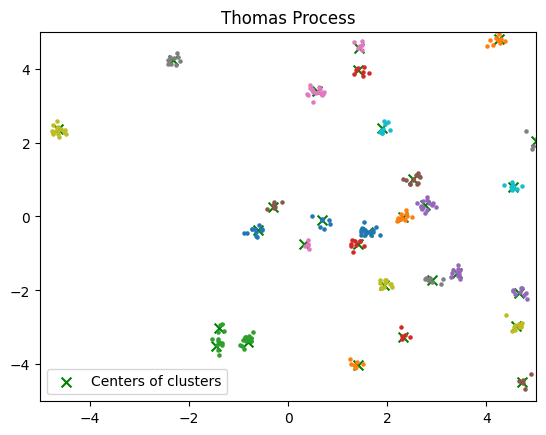

In [4]:
#First point process

centers_x1, centers_y1, points_x1, points_y1= Thomas_process(params['thomas_1']['L'],
                                                             params['thomas_1']['lam_p'],
                                                             params['thomas_1']['nu'],
                                                             params['thomas_1']['sig'])
N_c1=len(centers_x1)

plt.scatter(centers_x1, centers_y1, s=50, color='green', marker='x', label="Centers of clusters")
for i in range(N_c1):
    plt.scatter(points_x1[i], points_y1[i], s=5)


plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.legend()
plt.title("Thomas Process")
plt.show()

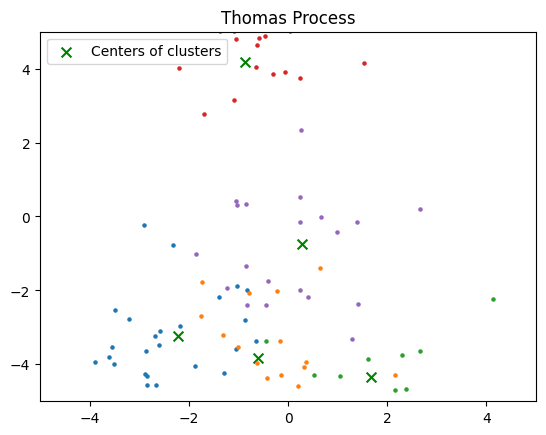

In [5]:
#Second point process

centers_x2, centers_y2, points_x2, points_y2= Thomas_process(params['thomas_2']['L'],
                                                             params['thomas_2']['lam_p'],
                                                             params['thomas_2']['nu'],
                                                             params['thomas_2']['sig'])
N_c2=len(centers_x2)

plt.scatter(centers_x2, centers_y2, s=50, color='green', marker='x', label="Centers of clusters")
for i in range(N_c2):
    plt.scatter(points_x2[i], points_y2[i], s=5)


plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.legend()
plt.title("Thomas Process")
plt.show()

In [6]:

def I(x,y,lambda_hat,points,area):
    n=lambda_hat

    for T in points:
        for D in points:
            if T==D:
                n+=0
            else:
                n+=(np.exp(-2*np.pi*1j*(x*(T[0]-D[0])+y*(T[1]-D[1]))))/area

    return n.real 

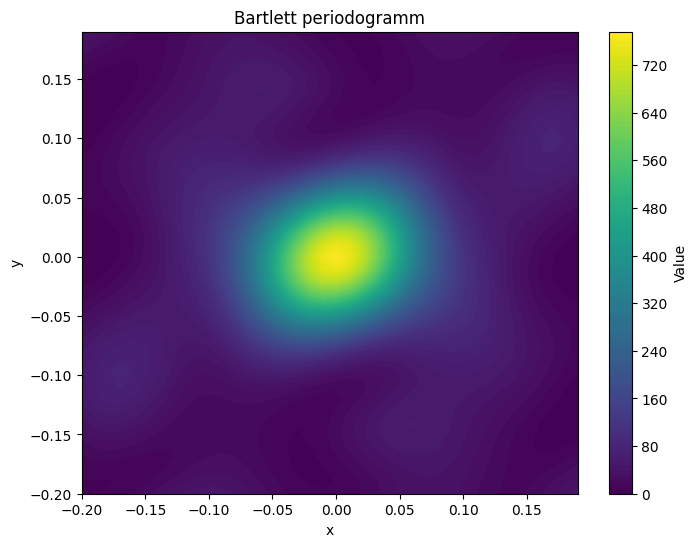

In [ ]:
#We want to plot the periodogramm
c=10
points1=[]

for i in range(len(points_x1)):
    for j in range (len(points_x1[i])):
        if points_x1[i][j]>=-c/2 and c/2>=points_x1[i][j] and points_y1[i][j]>=-c/2 and c/2>=points_y1[i][j]:
            points1.append([points_x1[i][j],points_y1[i][j]])

area=c**2
lambda_hat=len(points1)/area

x=np.arange(-0.2,0.2,0.01)
y=np.arange(-0.2,0.2,0.01)
X,Y= np.meshgrid(x,y)

Z=I(X,Y,lambda_hat,points1,area)

plt.figure(figsize=(8,6))
plt.contourf(X,Y,Z,100, cmap='viridis')
plt.colorbar(label='Value')
plt.title(f'Thomas($\lambda_p$ = {lam_p1: .2}, $\nu$ = {nu1: .2f}, $sig$ = {sig1: .2f})')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

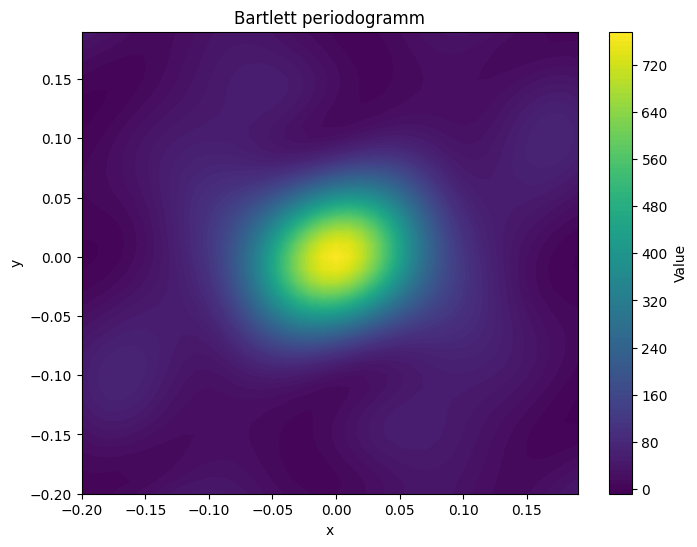

In [ ]:
#the second periodogramm

plt.rcParams.update({
    "text.usetex": True,          # Use LaTeX to render text
    "font.family": "serif",       # Match LaTeX serif font
    "font.size": 12
    })

c=10
points2=[]

for i in range(len(points_x2)):
    for j in range (len(points_x2[i])):
        if points_x2[i][j]>=-c/2 and c/2>=points_x2[i][j] and points_y2[i][j]>=-c/2 and c/2>=points_y2[i][j]:
            points2.append([points_x2[i][j],points_y2[i][j]])

area=c**2
lambda_hat=len(points2)/area

x=np.arange(-0.2,0.2,0.01)
y=np.arange(-0.2,0.2,0.01)
X,Y= np.meshgrid(x,y)

Z=I(X,Y,lambda_hat,points1,area)

plt.figure(figsize=(8,6))
plt.contourf(X,Y,Z,100, cmap='viridis')
plt.colorbar(label='Value')
plt.title(f'Thomas({lam_p1: .2}, {nu1: .2f}, {sig1: .2f}) + Thomas({lam_p2: .2}, {nu2: .2f}, {sig2: .2f})')
plt.xlabel('x')
plt.ylabel('y')
plt.savefig('../../img/bartlett-2.eps', format='eps')
plt.show()

Now, B is of side 20

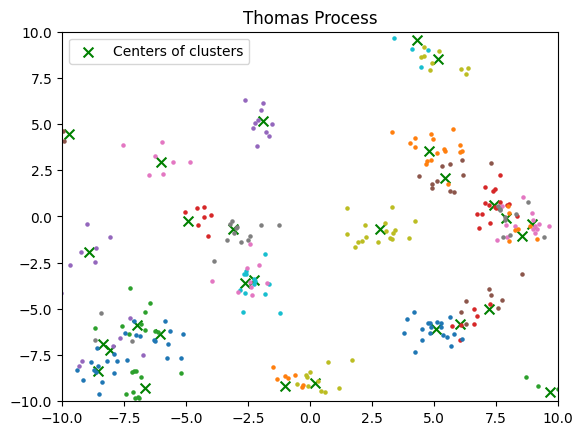

In [9]:
#First point process

centers_x1, centers_y1, points_x1, points_y1= Thomas_process(params['thomas_3']['L'],
                                                             params['thomas_3']['lam_p'],
                                                             params['thomas_3']['nu'],
                                                             params['thomas_3']['sig'])
N_c1=len(centers_x1)

plt.scatter(centers_x1, centers_y1, s=50, color='green', marker='x', label="Centers of clusters")
for i in range(N_c1):
    plt.scatter(points_x1[i], points_y1[i], s=5)


plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.legend()
plt.title("Thomas Process")
plt.show()

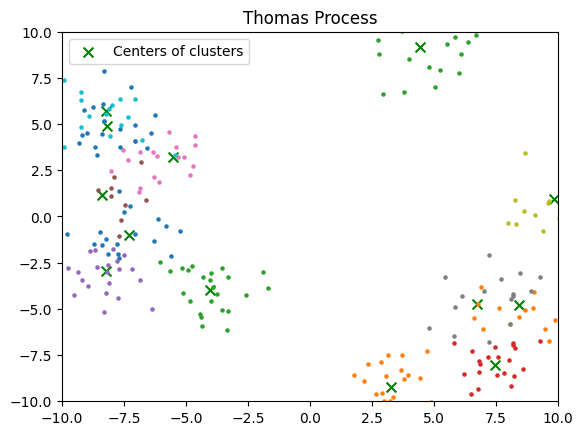

In [10]:
#Second point process

centers_x2, centers_y2, points_x2, points_y2= Thomas_process(params['thomas_4']['L'],
                                                             params['thomas_4']['lam_p'],
                                                             params['thomas_4']['nu'],
                                                             params['thomas_4']['sig'])
N_c2=len(centers_x2)

plt.scatter(centers_x2, centers_y2, s=50, color='green', marker='x', label="Centers of clusters")
for i in range(N_c2):
    plt.scatter(points_x2[i], points_y2[i], s=5)


plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.legend()
plt.title("Thomas Process")
plt.show()

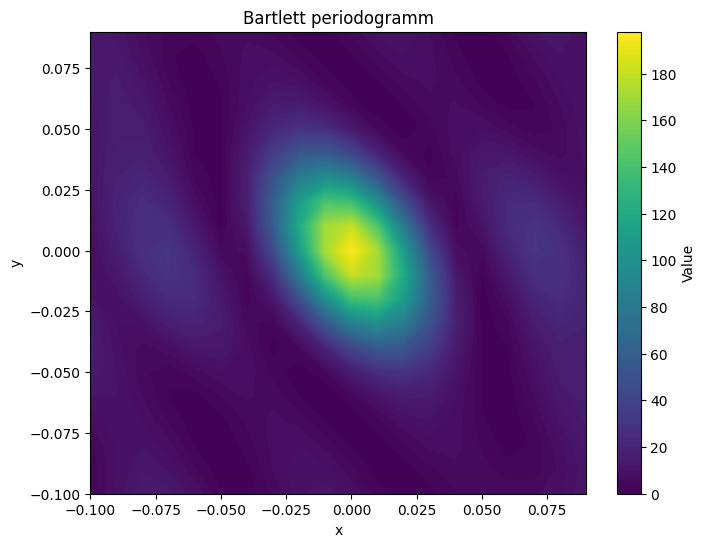

In [11]:
#We want to plot the periodogramm
c=20
points1=[]

for i in range(len(points_x1)):
    for j in range (len(points_x1[i])):
        if points_x1[i][j]>=-c/2 and c/2>=points_x1[i][j] and points_y1[i][j]>=-c/2 and c/2>=points_y1[i][j]:
            points1.append([points_x1[i][j],points_y1[i][j]])

area=c**2
lambda_hat=len(points1)/area

x=np.arange(-0.1,0.1,0.01)
y=np.arange(-0.1,0.1,0.01)
X,Y= np.meshgrid(x,y)

Z=I(X,Y,lambda_hat,points1,area)

plt.figure(figsize=(8,6))
plt.contourf(X,Y,Z,100, cmap='viridis')
plt.colorbar(label='Value')
plt.title('Bartlett periodogramm')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

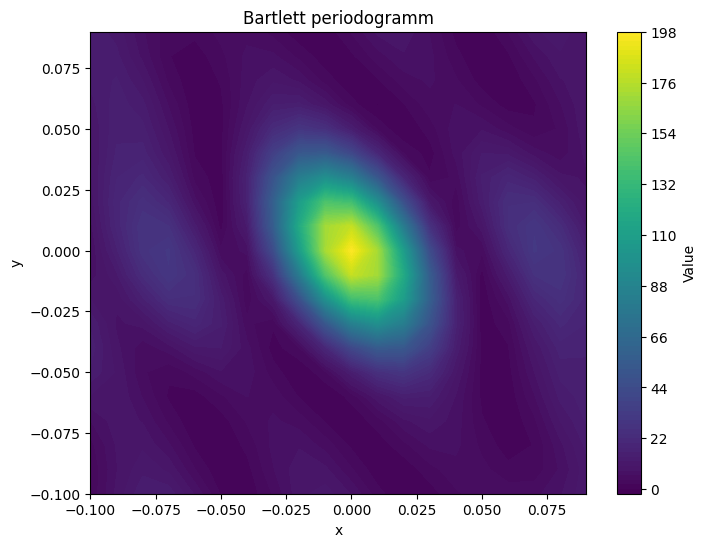

In [12]:
#the second periodogramm

c=20
points2=[]

for i in range(len(points_x2)):
    for j in range (len(points_x2[i])):
        if points_x2[i][j]>=-c/2 and c/2>=points_x2[i][j] and points_y2[i][j]>=-c/2 and c/2>=points_y2[i][j]:
            points2.append([points_x2[i][j],points_y2[i][j]])

area=c**2
lambda_hat=len(points2)/area

x=np.arange(-0.1,0.1,0.01)
y=np.arange(-0.1,0.1,0.01)
X,Y= np.meshgrid(x,y)

Z=I(X,Y,lambda_hat,points1,area)

plt.figure(figsize=(8,6))
plt.contourf(X,Y,Z,100, cmap='viridis')
plt.colorbar(label='Value')
plt.title('Bartlett periodogramm')
plt.xlabel('x')
plt.ylabel('y')
plt.show()